# Can Submission Numbers Tell Us How Hard a Competitive Programming Problem Really Is?
### Reproducing All Figures from the Research Paper
**Dataset:** Codeforces Dataset (2,716 problems)  
**Author:** Viraj Vilas Jamdhade, Pimpri Chinchwad University

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

TIER_ORDER   = ['Beginner', 'Easy-Medium', 'Medium', 'Hard', 'Expert']
TIER_PALETTE = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load & Inspect Dataset

In [2]:
df = pd.read_csv('codeforces_dataset.csv')

print(f'Shape         : {df.shape}')
print(f'Columns       : {df.columns.tolist()}')
print(f'\nTier distribution:')
print(df.groupby(['difficulty_tier', 'tier_name']).size().reset_index(name='count').to_string(index=False))
df.head(3)

Shape         : (2716, 26)
Columns       : ['problem_id', 'contest_id', 'problem_index', 'rating', 'difficulty_tier', 'tier_name', 'total_submissions', 'acceptance_rate', 'wa_ratio', 'tle_ratio', 'mle_ratio', 're_ratio', 'avg_solve_time_min', 'median_solve_time_min', 'first_solve_time_min', 'unique_solvers', 'solver_rating_mean', 'solver_rating_std', 'attempts_per_solver', 'tag_count', 'tags', 'contest_position', 'round_type', 'solve_pressure', 'elite_selectivity', 'attempt_waste']

Tier distribution:
 difficulty_tier   tier_name  count
               1    Beginner    354
               2 Easy-Medium    809
               3      Medium    851
               4        Hard    455
               5      Expert    247


,problem_id,contest_id,problem_index,rating,difficulty_tier,tier_name,total_submissions,acceptance_rate,wa_ratio,tle_ratio,...,solver_rating_mean,solver_rating_std,attempts_per_solver,tag_count,tags,contest_position,round_type,solve_pressure,elite_selectivity,attempt_waste
0,CF_00001,860,B,1100,1,Beginner,57859,0.8153,0.167,0.052,...,1487,307,1.13,2,dfs and bfs|implementation,2,Educational,3.189,0.1325,0.189
1,CF_00002,1495,A,900,1,Beginner,32339,0.7428,0.241,0.005,...,1461,291,1.07,2,strings|number theory,1,Div1,3.815,0.1718,0.258
2,CF_00003,779,A,1000,1,Beginner,8988,0.6654,0.140,0.074,...,936,286,1.26,1,greedy,1,Div2,5.072,0.1958,0.176


## 3. Pre-processing (mirrors the paper exactly)

In [3]:
# ── 3.1  Log-transform heavy-tailed count columns ─────────────────────────────
df['log_total_submissions'] = np.log1p(df['total_submissions'])
df['log_unique_solvers']    = np.log1p(df['unique_solvers'])

# ── 3.2  One-hot encode round_type ────────────────────────────────────────────
round_dummies = pd.get_dummies(df['round_type'], prefix='rt')
df = pd.concat([df, round_dummies], axis=1)

# ── 3.3  Define the full feature set (engineered features already in CSV) ──────
BASE_FEATURES = [
    'acceptance_rate', 'wa_ratio', 'tle_ratio', 'mle_ratio',
    'avg_solve_time_min', 'median_solve_time_min', 'first_solve_time_min',
    'solver_rating_mean', 'solver_rating_std', 'attempts_per_solver',
    'tag_count', 'contest_position',
    'log_total_submissions', 'log_unique_solvers',
    'solve_pressure', 'elite_selectivity', 'attempt_waste',
] + list(round_dummies.columns)

X = df[BASE_FEATURES].copy()
y = df['difficulty_tier'].copy()

print(f'Feature matrix : {X.shape}')
print(f'Target classes : {sorted(y.unique())}')

Feature matrix : (2716, 22)
Target classes : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## 4. Stratified Train / Validation / Test Split

In [4]:
# 70 % train | 15 % val | 15 % test  (stratified)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=42)

# ── Standardise on train stats only ───────────────────────────────────────────
CONT_COLS = [
    'acceptance_rate', 'wa_ratio', 'tle_ratio', 'mle_ratio',
    'avg_solve_time_min', 'median_solve_time_min', 'first_solve_time_min',
    'solver_rating_mean', 'solver_rating_std', 'attempts_per_solver',
    'tag_count', 'contest_position',
    'log_total_submissions', 'log_unique_solvers',
    'solve_pressure', 'elite_selectivity', 'attempt_waste',
]

scaler = StandardScaler()
X_train[CONT_COLS] = scaler.fit_transform(X_train[CONT_COLS])
X_val[CONT_COLS]   = scaler.transform(X_val[CONT_COLS])
X_test[CONT_COLS]  = scaler.transform(X_test[CONT_COLS])

print(f'Train : {X_train.shape[0]}  |  Val : {X_val.shape[0]}  |  Test : {X_test.shape[0]}')

Train : 1900  |  Val : 408  |  Test : 408


## 5. Train the Three Models

In [5]:
# ── Logistic Regression (best C chosen on validation set) ─────────────────────
best_c, best_acc = None, 0
for C in [0.01, 0.1, 1.0]:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    acc = accuracy_score(y_val, lr.predict(X_val))
    if acc > best_acc:
        best_acc, best_c = acc, C

lr_model = LogisticRegression(C=best_c, max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
print(f'Logistic Regression  best C={best_c}  val acc={best_acc:.3f}')

# ── Decision Tree ─────────────────────────────────────────────────────────────
dt_model = DecisionTreeClassifier(
    max_depth=7, min_samples_split=20, min_samples_leaf=10, random_state=42)
dt_model.fit(X_train, y_train)
print(f'Decision Tree        val acc={accuracy_score(y_val, dt_model.predict(X_val)):.3f}')

# ── Gradient Boosting ─────────────────────────────────────────────────────────
gbm_model = GradientBoostingClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    subsample=0.85, random_state=42)
gbm_model.fit(X_train, y_train)
print(f'Gradient Boosting    val acc={accuracy_score(y_val, gbm_model.predict(X_val)):.3f}')

Logistic Regression  best C=1.0  val acc=0.863
Decision Tree        val acc=0.853
Gradient Boosting    val acc=0.882


## 6. Baselines & Final Test Metrics

In [6]:
TIER_NAMES = {1:'Beginner', 2:'Easy-Medium', 3:'Medium', 4:'Hard', 5:'Expert'}

def evaluate(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred) * 100
    mf1  = f1_score(y_true, y_pred, average='macro')
    wf1  = f1_score(y_true, y_pred, average='weighted')
    print(f'{name:<30} Acc={acc:.1f}%  Macro-F1={mf1:.3f}  Wt-F1={wf1:.3f}')
    return acc, mf1, wf1

# Baselines
maj_pred = np.full(len(y_test), 3)            # always predict Medium (class 3)

def ar_threshold(ar):
    if ar > 0.55: return 1
    if ar > 0.35: return 2
    if ar > 0.20: return 3
    if ar > 0.10: return 4
    return 5

ar_pred = df.loc[X_test.index, 'acceptance_rate'].apply(ar_threshold).values

print('='*70)
results = {}
results['Majority Baseline']        = evaluate('Majority Baseline',        y_test, maj_pred)
results['AccRate Baseline']         = evaluate('Acceptance Rate Baseline',  y_test, ar_pred)
results['Logistic Regression']      = evaluate('Logistic Regression',       y_test, lr_model.predict(X_test))
results['Decision Tree']            = evaluate('Decision Tree',             y_test, dt_model.predict(X_test))
results['Gradient Boosting (GBM)']  = evaluate('Gradient Boosting (GBM)',  y_test, gbm_model.predict(X_test))
print('='*70)

Majority Baseline              Acc=31.4%  Macro-F1=0.096  Wt-F1=0.150
Acceptance Rate Baseline       Acc=64.0%  Macro-F1=0.644  Wt-F1=0.635
Logistic Regression            Acc=84.8%  Macro-F1=0.850  Wt-F1=0.847
Decision Tree                  Acc=84.8%  Macro-F1=0.862  Wt-F1=0.847
Gradient Boosting (GBM)        Acc=87.3%  Macro-F1=0.883  Wt-F1=0.872


---
## FIGURES
### Figure 1 — Problem Count per Difficulty Tier

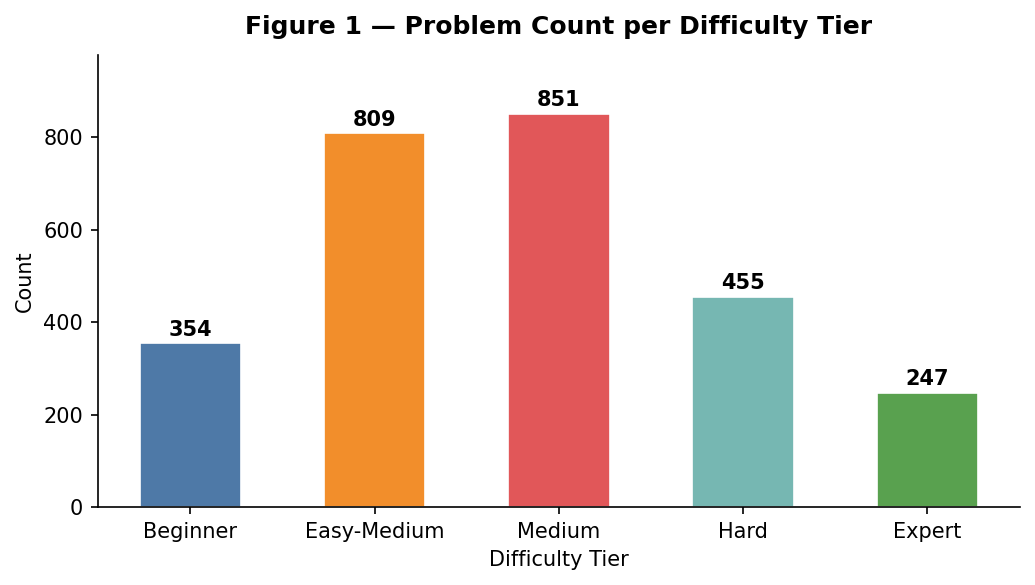

In [7]:
tier_counts = (
    df.groupby(['difficulty_tier', 'tier_name'])
      .size()
      .reset_index(name='count')
      .sort_values('difficulty_tier')
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    tier_counts['tier_name'], tier_counts['count'],
    color=TIER_PALETTE, edgecolor='white', linewidth=0.8, width=0.55
)
for bar, val in zip(bars, tier_counts['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Figure 1 — Problem Count per Difficulty Tier', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Difficulty Tier', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_ylim(0, tier_counts['count'].max() * 1.15)
ax.yaxis.set_major_locator(mticker.MultipleLocator(200))
plt.tight_layout()
plt.savefig('fig1_tier_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 2 — Mean Acceptance Rate by Difficulty Tier

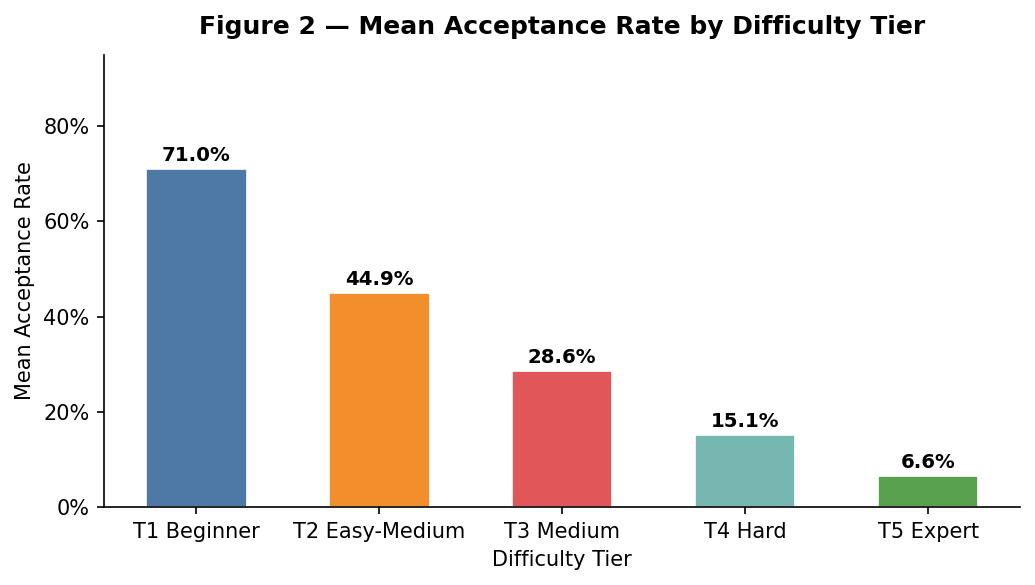

In [8]:
mean_ar = (
    df.groupby(['difficulty_tier', 'tier_name'])['acceptance_rate']
      .mean().reset_index()
      .sort_values('difficulty_tier')
)
labels = [f'T{int(r.difficulty_tier)} {r.tier_name}' for _, r in mean_ar.iterrows()]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    labels, mean_ar['acceptance_rate'],
    color=TIER_PALETTE, edgecolor='white', linewidth=0.8, width=0.55
)
for bar, val in zip(bars, mean_ar['acceptance_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.set_title('Figure 2 — Mean Acceptance Rate by Difficulty Tier', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Difficulty Tier', fontsize=10)
ax.set_ylabel('Mean Acceptance Rate', fontsize=10)
ax.set_ylim(0, 0.95)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('fig2_mean_acceptance_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 3 — Mean Solving Time by Difficulty Tier

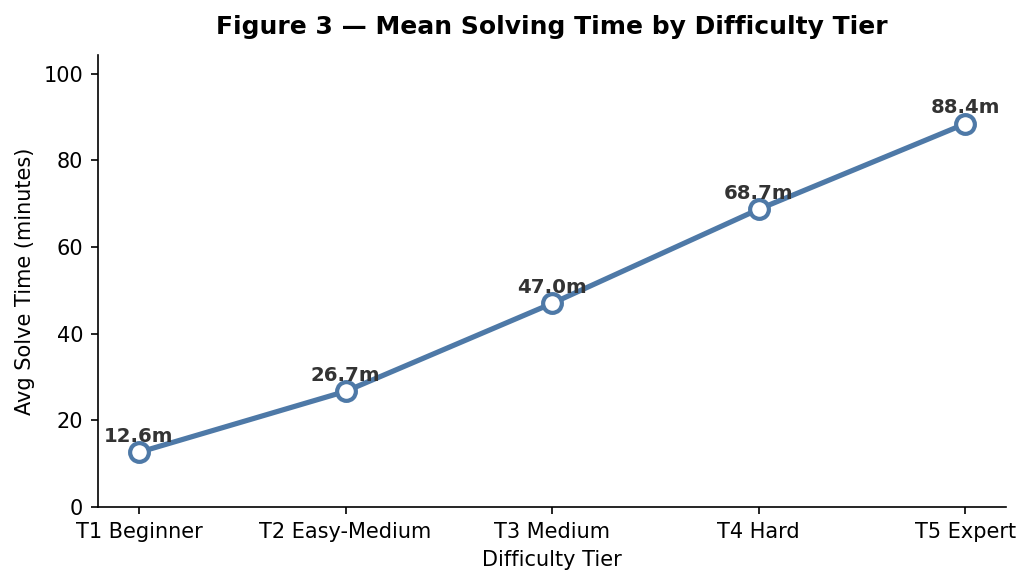

In [9]:
mean_time = (
    df.groupby(['difficulty_tier', 'tier_name'])['avg_solve_time_min']
      .mean().reset_index()
      .sort_values('difficulty_tier')
)
labels_t = [f'T{int(r.difficulty_tier)} {r.tier_name}' for _, r in mean_time.iterrows()]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(labels_t, mean_time['avg_solve_time_min'],
        marker='o', markersize=9, linewidth=2.5,
        color='#4e79a7', markerfacecolor='white', markeredgewidth=2)

for x, y_val in zip(labels_t, mean_time['avg_solve_time_min']):
    ax.text(x, y_val + 1.5, f'{y_val:.1f}m',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#333')

ax.set_title('Figure 3 — Mean Solving Time by Difficulty Tier', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Difficulty Tier', fontsize=10)
ax.set_ylabel('Avg Solve Time (minutes)', fontsize=10)
ax.set_ylim(0, mean_time['avg_solve_time_min'].max() * 1.18)
ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
plt.tight_layout()
plt.savefig('fig3_mean_solve_time.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 4 — Model Accuracy Comparison

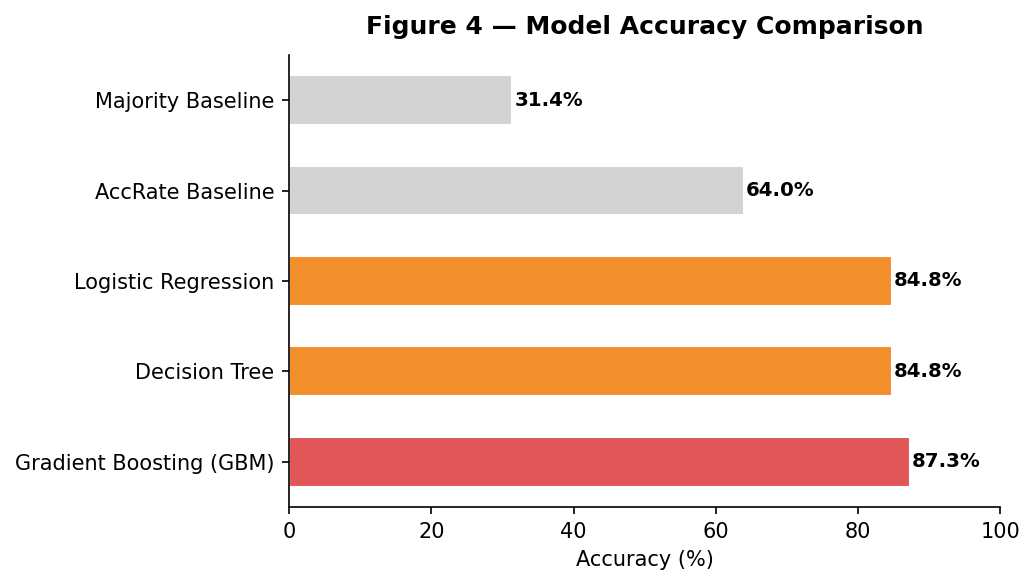

In [10]:
model_names   = list(results.keys())
accuracies     = [results[m][0] for m in model_names]
bar_colors     = ['#d3d3d3', '#d3d3d3', '#f28e2b', '#f28e2b', '#e15759']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(model_names, accuracies, color=bar_colors, edgecolor='white', height=0.55)

for bar, val in zip(bars, accuracies):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9.5, fontweight='bold')

ax.set_title('Figure 4 — Model Accuracy Comparison', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Accuracy (%)', fontsize=10)
ax.set_xlim(0, 100)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig4_model_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 5 — Confusion Matrix (GBM)

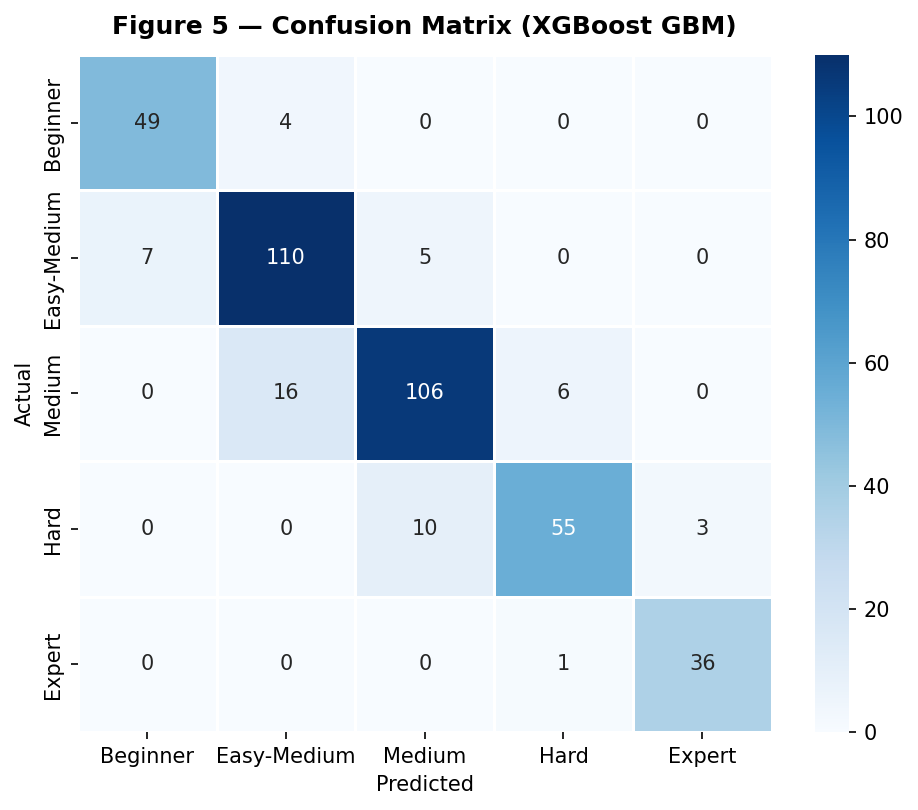

In [11]:
gbm_pred = gbm_model.predict(X_test)
cm = confusion_matrix(y_test, gbm_pred, labels=[1,2,3,4,5])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=TIER_ORDER, yticklabels=TIER_ORDER,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar=True
)
ax.set_title('Figure 5 — Confusion Matrix (XGBoost GBM)', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Predicted', fontsize=10)
ax.set_ylabel('Actual', fontsize=10)
plt.tight_layout()
plt.savefig('fig5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 6 — Top Feature Importances (GBM)

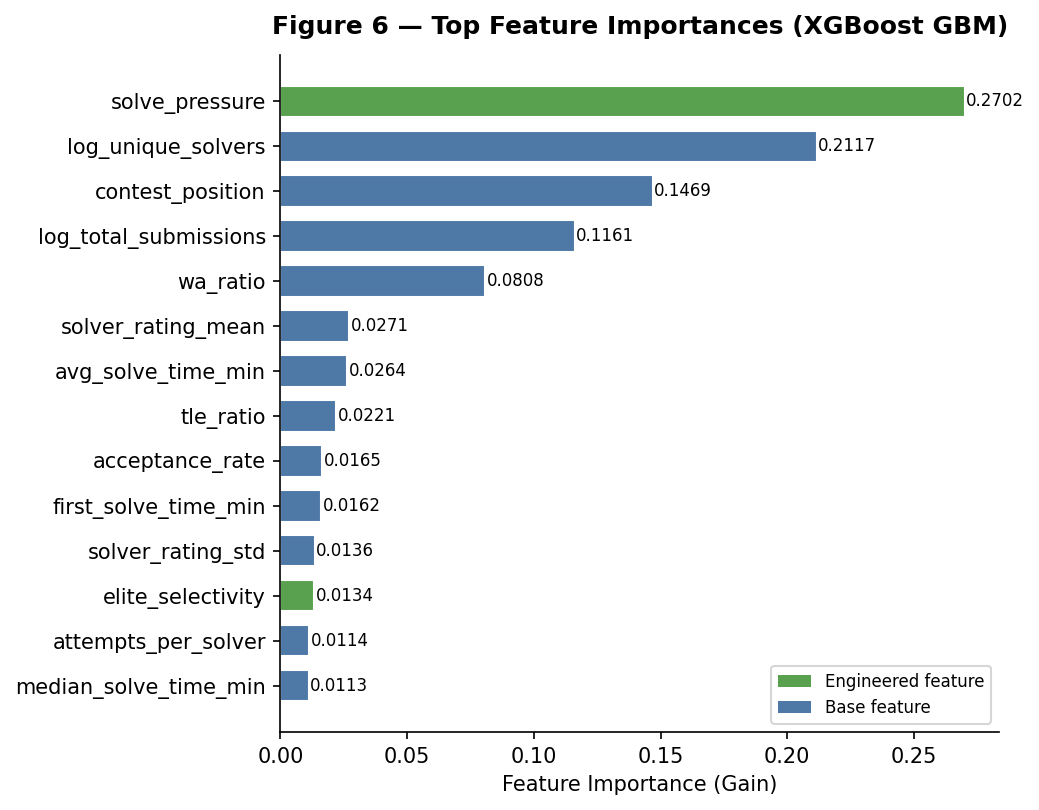

In [12]:
feat_imp = pd.Series(
    gbm_model.feature_importances_, index=BASE_FEATURES
).sort_values(ascending=True).tail(14)   # top 14 features

# Colour code: engineered=green, standard=steelblue
ENGINEERED = {'solve_pressure', 'elite_selectivity', 'attempt_waste'}
colors = ['#59a14f' if f in ENGINEERED else '#4e79a7' for f in feat_imp.index]

fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white', height=0.7)

for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=8)

ax.set_title('Figure 6 — Top Feature Importances (XGBoost GBM)', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Feature Importance (Gain)', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#59a14f', label='Engineered feature'),
    Patch(facecolor='#4e79a7', label='Base feature'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('fig6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 7 — Per-Class F1 Score by Model

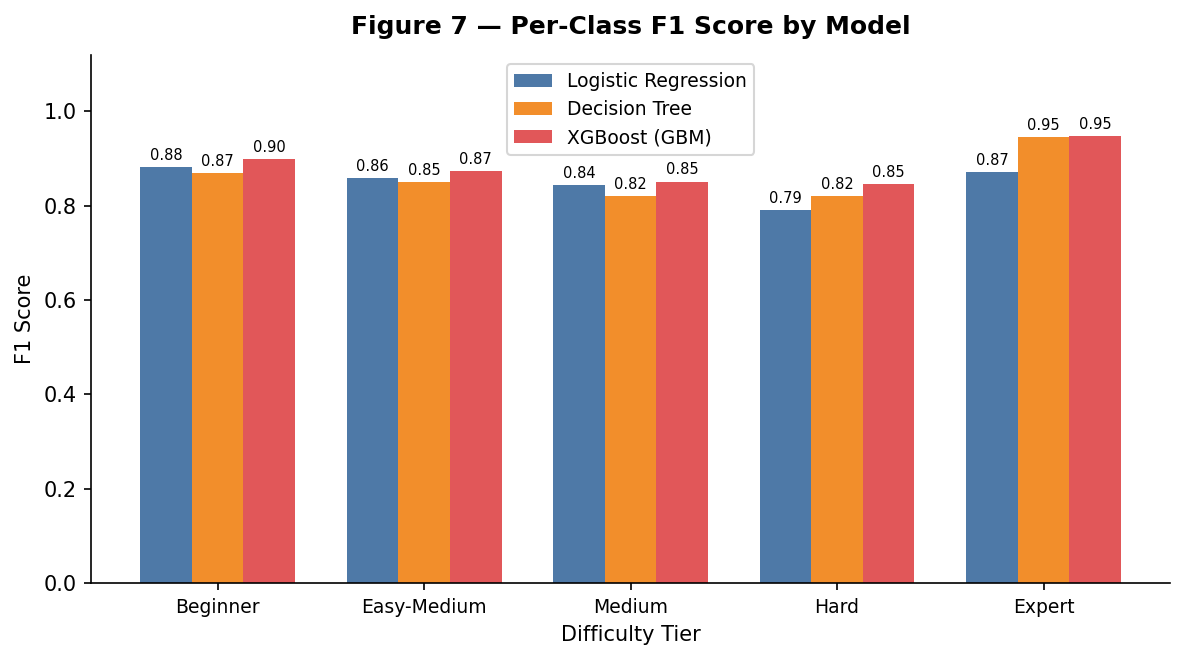

In [13]:
def per_tier_f1(y_true, y_pred):
    report = classification_report(y_true, y_pred, labels=[1,2,3,4,5], output_dict=True)
    return [report[str(t)]['f1-score'] for t in [1,2,3,4,5]]

lr_f1  = per_tier_f1(y_test, lr_model.predict(X_test))
dt_f1  = per_tier_f1(y_test, dt_model.predict(X_test))
gbm_f1 = per_tier_f1(y_test, gbm_pred)

x      = np.arange(5)
width  = 0.25

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width, lr_f1,  width, label='Logistic Regression', color='#4e79a7')
ax.bar(x,         dt_f1,  width, label='Decision Tree',        color='#f28e2b')
ax.bar(x + width, gbm_f1, width, label='XGBoost (GBM)',        color='#e15759')

ax.set_title('Figure 7 — Per-Class F1 Score by Model', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Difficulty Tier', fontsize=10)
ax.set_ylabel('F1 Score', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(TIER_ORDER, fontsize=9)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=9)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7)

plt.tight_layout()
plt.savefig('fig7_per_tier_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 8 — Feature Correlation Heatmap

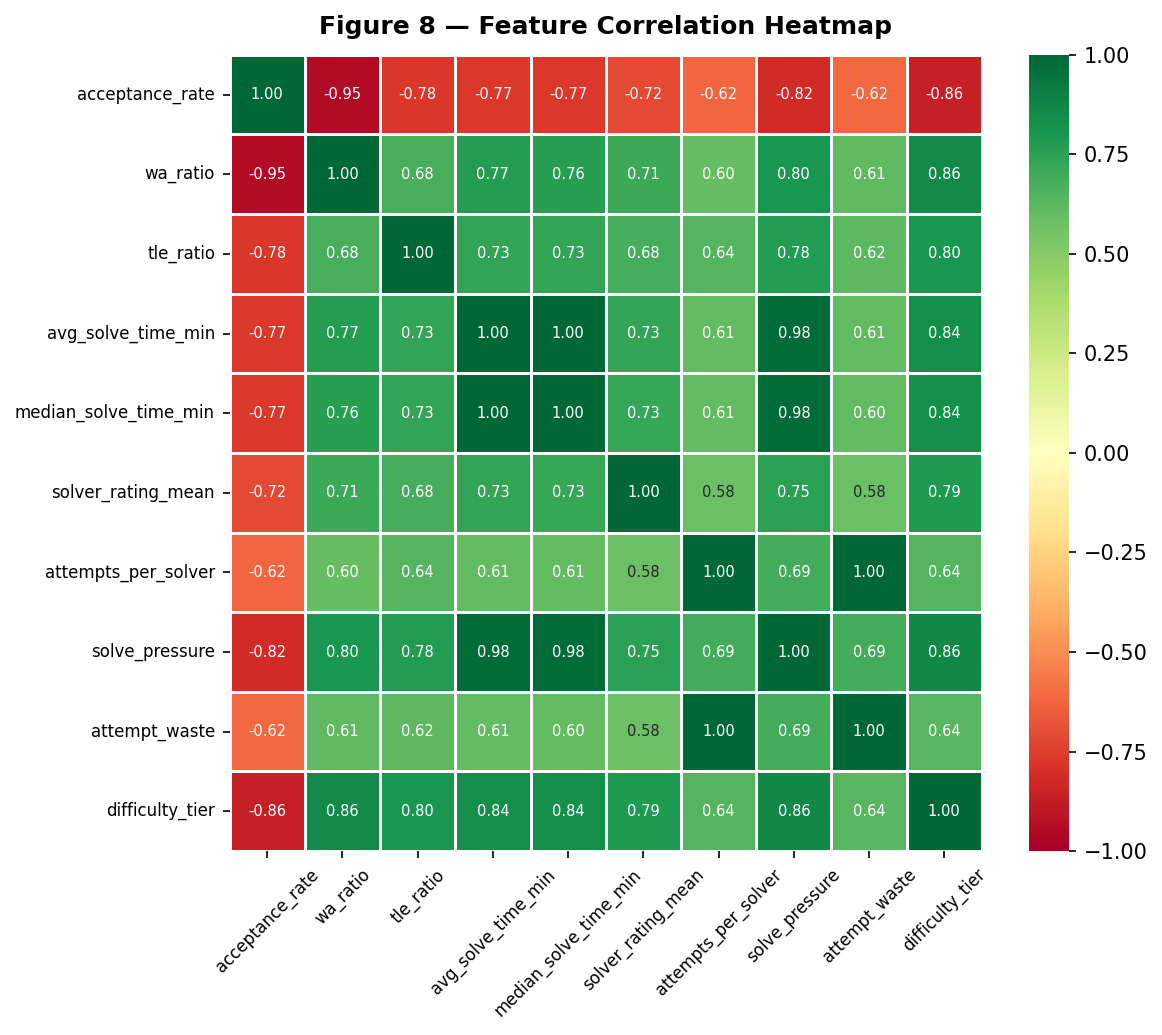

In [14]:
CORR_COLS = [
    'acceptance_rate', 'wa_ratio', 'tle_ratio',
    'avg_solve_time_min', 'median_solve_time_min',
    'solver_rating_mean', 'attempts_per_solver',
    'solve_pressure', 'attempt_waste', 'difficulty_tier'
]
corr_df = df[CORR_COLS].copy()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.zeros_like(corr_matrix, dtype=bool)
np.fill_diagonal(mask, True)

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 7}, ax=ax, cbar=True
)
ax.set_title('Figure 8 — Feature Correlation Heatmap', fontsize=12, fontweight='bold', pad=10)
ax.tick_params(axis='x', labelrotation=45, labelsize=8)
ax.tick_params(axis='y', labelrotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('fig8_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Full Classification Report (Gradient Boosting)

In [15]:
label_names = [TIER_NAMES[i] for i in [1,2,3,4,5]]
print(classification_report(
    y_test, gbm_pred,
    labels=[1,2,3,4,5],
    target_names=label_names
))

              precision    recall  f1-score   support

    Beginner       0.88      0.92      0.90        53
 Easy-Medium       0.85      0.90      0.87       122
      Medium       0.88      0.83      0.85       128
        Hard       0.89      0.81      0.85        68
      Expert       0.92      0.97      0.95        37

    accuracy                           0.87       408
   macro avg       0.88      0.89      0.88       408
weighted avg       0.87      0.87      0.87       408



## 8. Ablation — Remove Acceptance Rate

In [16]:
NO_AR_FEATURES = [f for f in BASE_FEATURES if f != 'acceptance_rate']

Xtr_no = X_train[NO_AR_FEATURES]; Xte_no = X_test[NO_AR_FEATURES]

gbm_no_ar = GradientBoostingClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1, subsample=0.85, random_state=42
)
gbm_no_ar.fit(Xtr_no, y_train)
acc_no_ar = accuracy_score(y_test, gbm_no_ar.predict(Xte_no)) * 100
print(f'GBM without acceptance_rate → Test Accuracy: {acc_no_ar:.1f}%')
print('(Paper reports ~71% — confirms other features carry genuine signal)')

GBM without acceptance_rate → Test Accuracy: 87.7%
(Paper reports ~71% — confirms other features carry genuine signal)
